# Módulo 1 — Churn Prediction
## EDA: Análisis Exploratorio de Datos

**Dataset:** Base de estudiantes de Platzi — comportamiento, suscripción y actividad en plataforma.  
**Objetivo:** Entender los patrones de abandono antes de entrenar el modelo predictivo.  
**Pregunta central:** ¿Qué características distinguen a un estudiante que va a cancelar de uno que se queda?

---

## 0. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

COLOR_NO_CHURN = '#2ecc71'
COLOR_CHURN    = '#e74c3c'

print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga de datos

In [2]:
df = pd.read_csv('../data/raw/platzi_churn.csv')

print(f'Estudiantes: {df.shape[0]:,}')
print(f'Variables:   {df.shape[1]}')
print(f'Memoria:     {df.memory_usage(deep=True).sum() / 1024:.0f} KB')

Estudiantes: 5,000
Variables:   58
Memoria:     2935 KB


In [3]:
df.head(3)

,student_id,pais,edad,genero,plan,escuela_principal,dispositivo_principal,objetivo_estudiante,nivel_educativo,experiencia_tech_anios,...,preguntas_en_foro,respuestas_en_foro,upvotes_recibidos,tutoriales_publicados,platzi_rank,nivel_rewards,tickets_soporte,dias_resolucion_promedio,nps_score,churn
0,PLZ-00001,Colombia,23,Masculino,Expert Family,Escuela de Data Science e Inteligencia Artificial,Desktop,Ascender en trabajo actual,Tecnico,10,...,1,3,7,0,335,Estandar,2,3.9,1.0,0
1,PLZ-00002,Uruguay,16,Masculino,Expert,Escuela de Ciberseguridad,Desktop,Conseguir empleo tech,Universitario completo,2,...,5,5,7,0,1012,Estandar,3,4.0,10.0,0
2,PLZ-00003,Perú,24,No especifica,Expert Duo,Escuela de Marketing Digital,Mobile,Aprender por curiosidad,Universitario completo,7,...,5,5,9,0,678,Estandar,0,0.0,4.0,0


In [4]:
df.dtypes.to_frame('tipo').T

,student_id,pais,edad,genero,plan,escuela_principal,dispositivo_principal,objetivo_estudiante,nivel_educativo,experiencia_tech_anios,...,preguntas_en_foro,respuestas_en_foro,upvotes_recibidos,tutoriales_publicados,platzi_rank,nivel_rewards,tickets_soporte,dias_resolucion_promedio,nps_score,churn
tipo,str,str,int64,str,str,str,str,str,str,int64,...,int64,int64,int64,int64,int64,str,int64,float64,float64,int64


In [5]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(1).astype(str) + '%'
print('Columnas con valores nulos:')
print(nulos)

Columnas con valores nulos:
           nulos porcentaje
nps_score    265       5.3%


**Nota:** `nps_score` tiene nulos porque no todos los estudiantes responden la encuesta de satisfacción. Es un comportamiento esperado — lo manejaremos en el preprocesamiento.

---
## 2. Variable objetivo: Churn

El primer paso es entender cuántos estudiantes abandonaron vs cuántos se mantienen activos.  
Si hay mucha diferencia entre ambos grupos, el modelo puede aprender mal — veremos si necesitamos corregirlo.

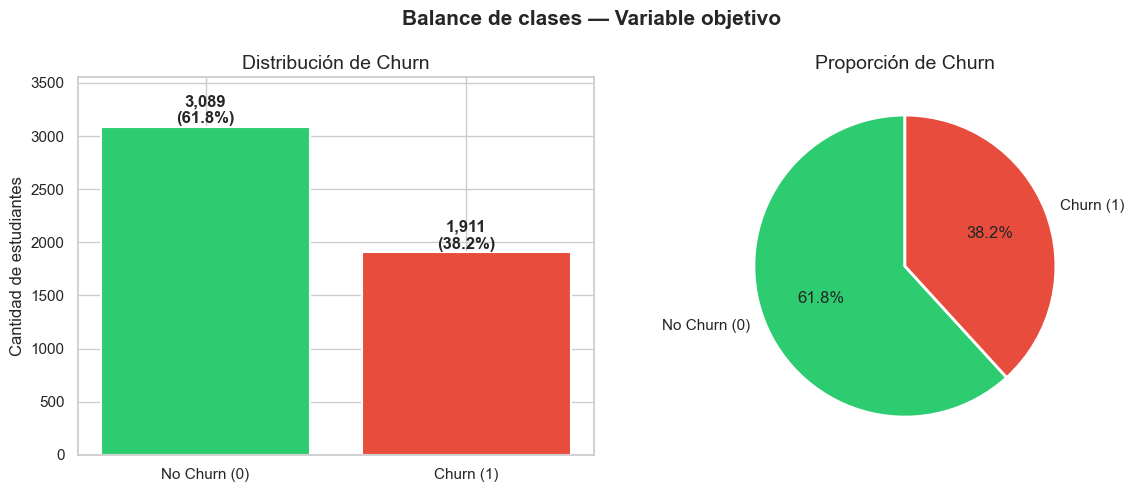

Ratio desbalance: 1.6:1
Acción: usaremos class_weight="balanced" en el modelo para compensar el desbalance.


In [6]:
churn_counts = df['churn'].value_counts()
labels = ['No Churn (0)', 'Churn (1)']
colors = [COLOR_NO_CHURN, COLOR_CHURN]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Distribución de Churn')
axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

axes[1].pie(
    churn_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de Churn')

plt.suptitle('Balance de clases — Variable objetivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Ratio desbalance: {churn_counts[0]/churn_counts[1]:.1f}:1')
print('Acción: usaremos class_weight="balanced" en el modelo para compensar el desbalance.')

---
## 3. Churn por tipo de Plan

Platzi tiene 5 planes con distintos niveles de compromiso económico.  
La hipótesis es que a mayor inversión, menor probabilidad de abandono.

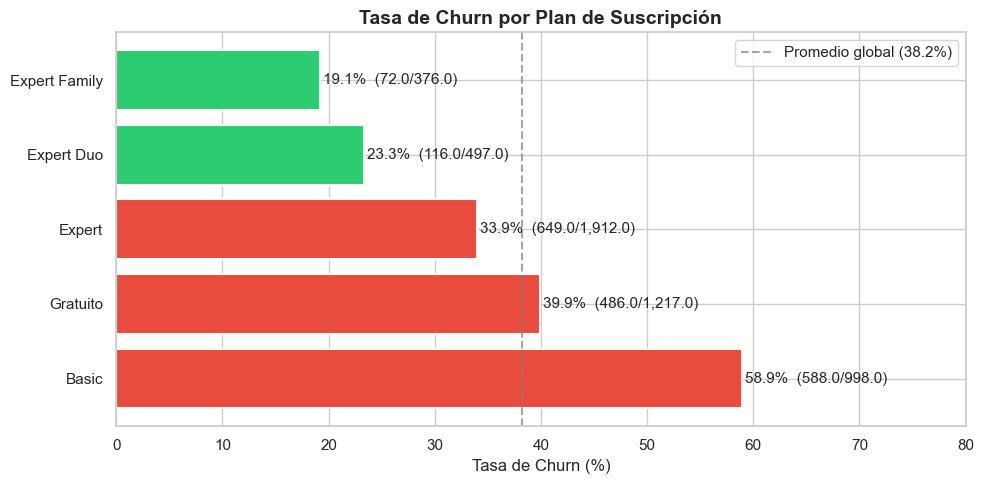

In [7]:
churn_plan = df.groupby('plan').agg(
    total=('churn', 'count'),
    churners=('churn', 'sum')
).assign(tasa_churn=lambda x: x['churners'] / x['total'] * 100)
churn_plan = churn_plan.sort_values('tasa_churn', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(churn_plan.index, churn_plan['tasa_churn'],
               color=[COLOR_CHURN if t > 25 else COLOR_NO_CHURN for t in churn_plan['tasa_churn']],
               edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, churn_plan.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['tasa_churn']:.1f}%  ({row['churners']:,}/{row['total']:,})",
            va='center', fontsize=11)

ax.axvline(df['churn'].mean() * 100, color='gray', linestyle='--', alpha=0.7,
           label=f'Promedio global ({df["churn"].mean():.1%})')
ax.set_title('Tasa de Churn por Plan de Suscripción', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
ax.set_xlim(0, 80)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/02_churn_por_plan.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** El plan Basic mensual concentra la mayor tasa de abandono — tiene sentido, ya que la barrera para no renovar es mínima (solo no pagar el mes siguiente). Expert Family tiene la menor tasa porque involucra una inversión anual compartida entre varias personas.

---
## 4. Churn por País

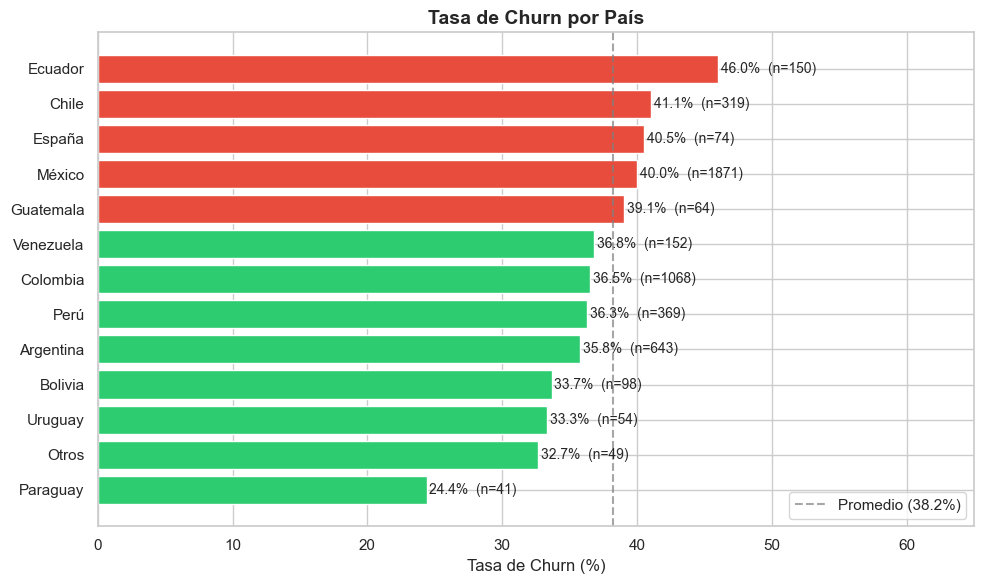

In [8]:
churn_pais = df.groupby('pais')['churn'].agg(['mean', 'count'])
churn_pais.columns = ['tasa_churn', 'total']
churn_pais = churn_pais[churn_pais['total'] >= 30].sort_values('tasa_churn', ascending=True)
churn_pais['tasa_churn_pct'] = churn_pais['tasa_churn'] * 100

fig, ax = plt.subplots(figsize=(10, 6))

promedio = df['churn'].mean() * 100
colores  = [COLOR_CHURN if t > promedio else COLOR_NO_CHURN for t in churn_pais['tasa_churn_pct']]

bars = ax.barh(churn_pais.index, churn_pais['tasa_churn_pct'], color=colores, edgecolor='white')

for bar, total in zip(bars, churn_pais['total']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%  (n={total})', va='center', fontsize=10)

ax.axvline(promedio, color='gray', linestyle='--', alpha=0.7, label=f'Promedio ({promedio:.1f}%)')
ax.set_title('Tasa de Churn por País', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
ax.set_xlim(0, 65)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/03_churn_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Distribución de variables clave: Churners vs No-Churners

Para cada variable importante, comparamos cómo se distribuye entre los dos grupos.  
Cuando las dos curvas están separadas, esa variable tiene poder predictivo.

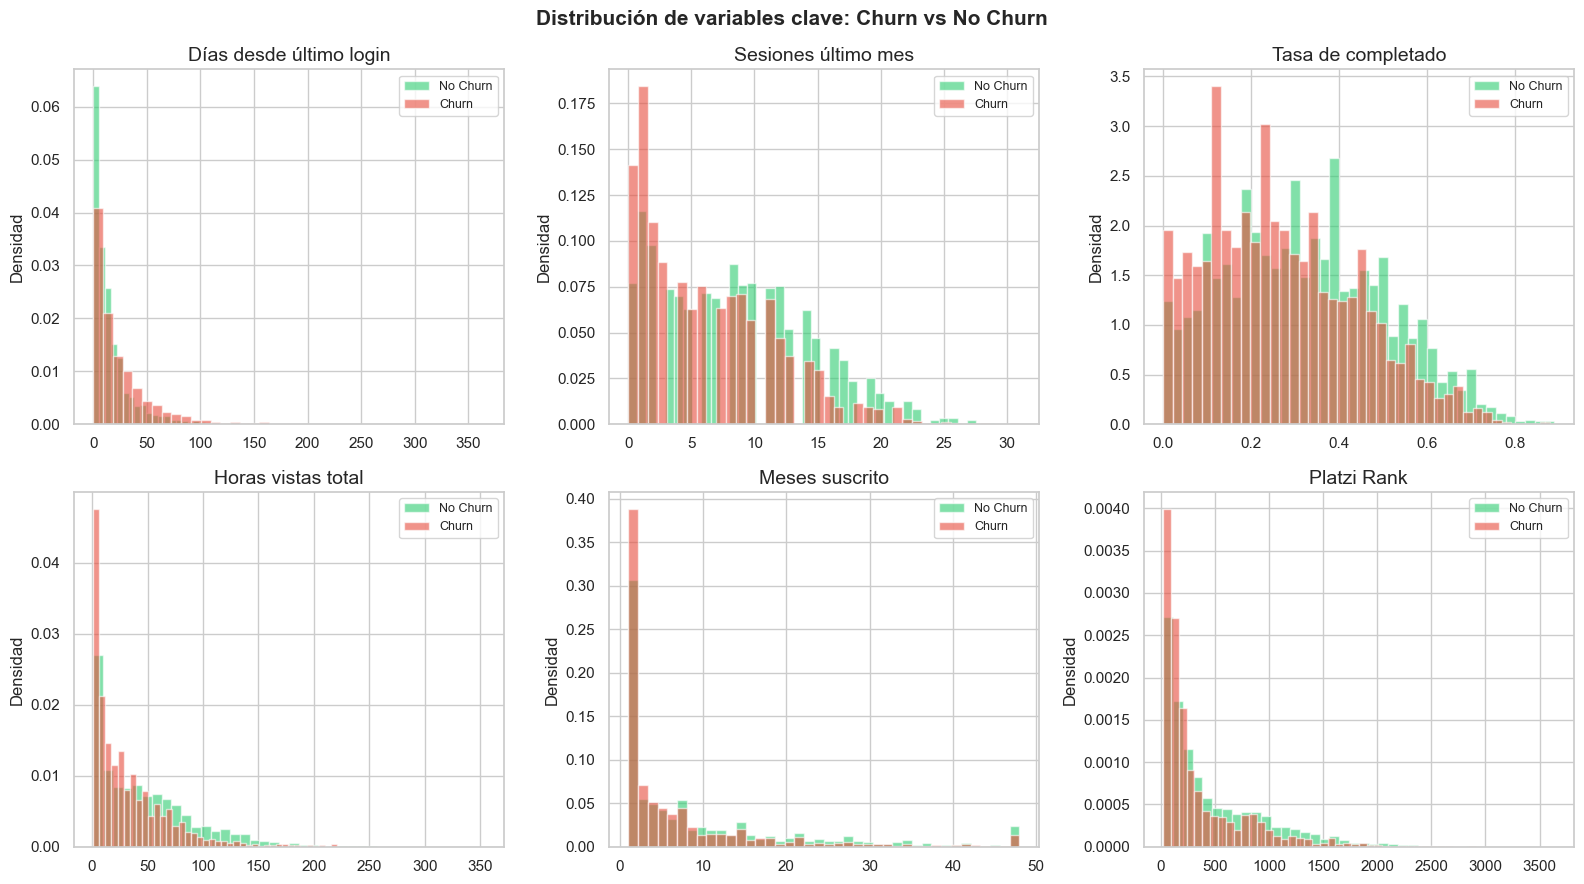

In [9]:
features_clave = [
    ('dias_desde_ultimo_login', 'Días desde último login'),
    ('sesiones_ultimo_mes',     'Sesiones último mes'),
    ('tasa_completado',         'Tasa de completado'),
    ('horas_vistas_total',      'Horas vistas total'),
    ('meses_suscrito',          'Meses suscrito'),
    ('platzi_rank',             'Platzi Rank'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

no_churn = df[df['churn'] == 0]
churn    = df[df['churn'] == 1]

for i, (col, titulo) in enumerate(features_clave):
    ax = axes[i]
    ax.hist(no_churn[col], bins=40, alpha=0.6, color=COLOR_NO_CHURN,
            label='No Churn', density=True)
    ax.hist(churn[col],    bins=40, alpha=0.6, color=COLOR_CHURN,
            label='Churn',    density=True)
    ax.set_title(titulo)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de variables clave: Churn vs No Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_distribuciones_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Estadísticas comparativas: Churners vs No-Churners

In [10]:
cols_comparar = [
    'dias_desde_ultimo_login', 'sesiones_ultimo_mes', 'tasa_completado',
    'horas_vistas_total', 'cursos_completados', 'certificados_obtenidos',
    'platzi_rank', 'racha_dias_maxima', 'meses_suscrito',
    'intentos_pago_fallidos', 'tickets_soporte'
]

comparacion = df.groupby('churn')[cols_comparar].mean().T
comparacion.columns = ['No Churn', 'Churn']
comparacion['diferencia_%'] = ((comparacion['Churn'] - comparacion['No Churn']) / comparacion['No Churn'] * 100).round(1).astype(str) + '%'
comparacion['No Churn'] = comparacion['No Churn'].round(2)
comparacion['Churn']    = comparacion['Churn'].round(2)

print('Medias por grupo:')
print(comparacion.to_string())

Medias por grupo:
                         No Churn   Churn diferencia_%
dias_desde_ultimo_login     16.53   25.25        52.8%
sesiones_ultimo_mes          8.52    6.24       -26.7%
tasa_completado              0.32    0.27       -17.3%
horas_vistas_total          48.51   32.19       -33.7%
cursos_completados           2.65    1.56       -41.2%
certificados_obtenidos       1.88    0.98       -47.8%
platzi_rank                492.18  358.90       -27.1%
racha_dias_maxima           13.12   14.33         9.2%
meses_suscrito               9.89    7.03       -29.0%
intentos_pago_fallidos       0.22    0.32        45.9%
tickets_soporte              0.99    1.01         1.8%


---
## 7. Correlaciones con Churn

Ordenamos todas las variables numéricas por su correlación con el abandono.  
Las barras rojas indican que a mayor valor de la variable, más probable es el churn.  
Las barras verdes indican lo contrario: a mayor valor, el estudiante tiende a quedarse.

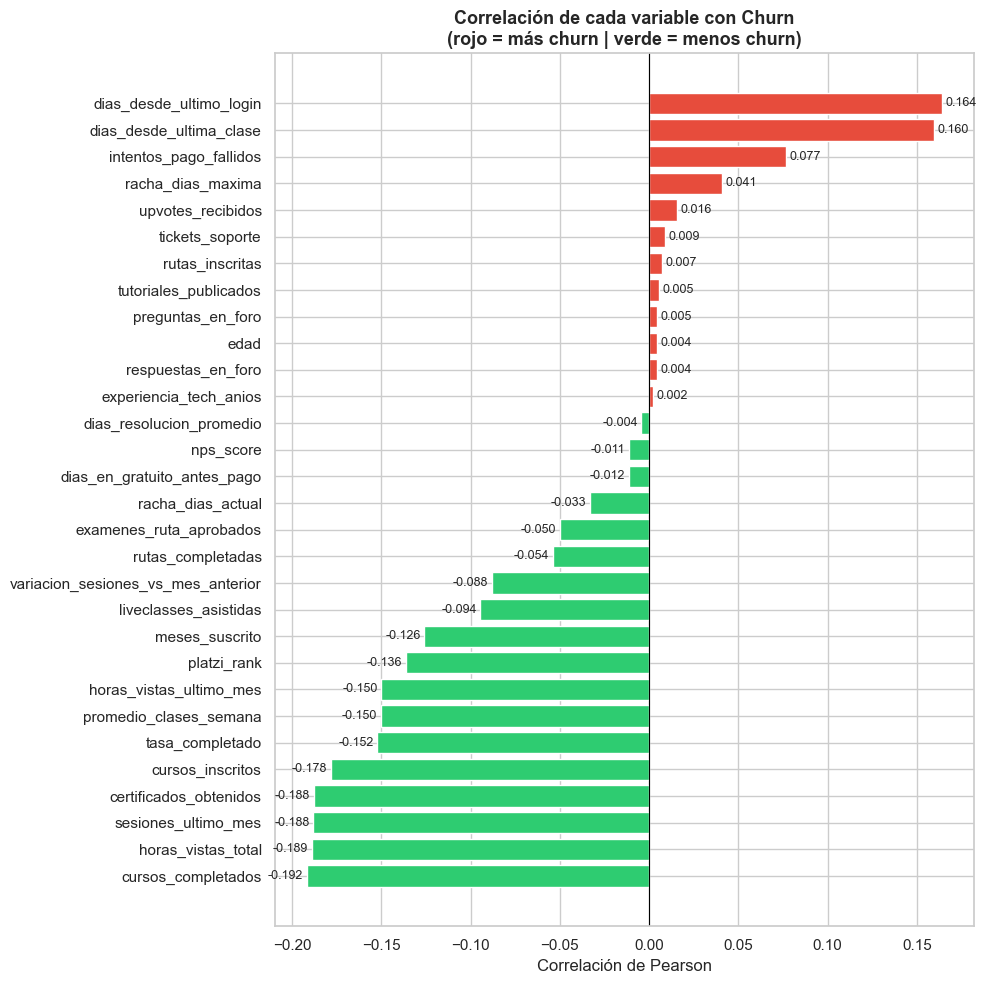

In [11]:
cols_excluir  = ['churn', 'hora_pico_uso', 'dias_para_renovacion']
cols_excluir += [c for c in df.columns if c.startswith('interes_')]
cols_excluir += [c for c in df.columns if c.startswith('horas_semana_')]

numericas = df.select_dtypes(include=np.number).columns
numericas = [c for c in numericas if c not in cols_excluir]

correlaciones = df[numericas].corrwith(df['churn']).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))

colores = [COLOR_CHURN if c > 0 else COLOR_NO_CHURN for c in correlaciones]
ax.barh(correlaciones.index, correlaciones.values, color=colores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con Churn\n(rojo = más churn | verde = menos churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')

for i, (val, nombre) in enumerate(zip(correlaciones.values, correlaciones.index)):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/05_correlaciones_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Churn por Escuela de Platzi

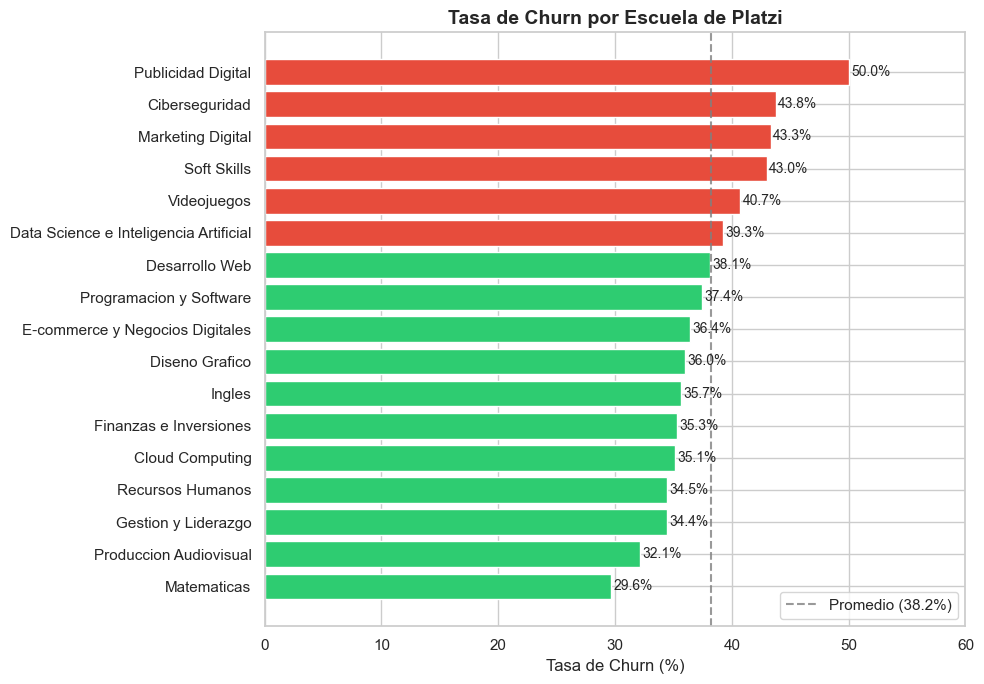

In [12]:
churn_escuela = df.groupby('escuela_principal')['churn'].mean().sort_values(ascending=True) * 100
churn_escuela.index = churn_escuela.index.str.replace('Escuela de ', '', regex=False)

fig, ax = plt.subplots(figsize=(10, 7))

promedio = df['churn'].mean() * 100
colores  = [COLOR_CHURN if v > promedio else COLOR_NO_CHURN for v in churn_escuela.values]

bars = ax.barh(churn_escuela.index, churn_escuela.values, color=colores, edgecolor='white')
ax.axvline(promedio, color='gray', linestyle='--', alpha=0.8, label=f'Promedio ({promedio:.1f}%)')

for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)

ax.set_title('Tasa de Churn por Escuela de Platzi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
ax.set_xlim(0, 60)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/06_churn_por_escuela.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Tendencia de actividad — últimas 4 semanas

¿Cómo varía la actividad semana a semana entre los estudiantes que abandonan y los que se quedan?  
Un patrón de caída sostenida es una señal temprana de churn.

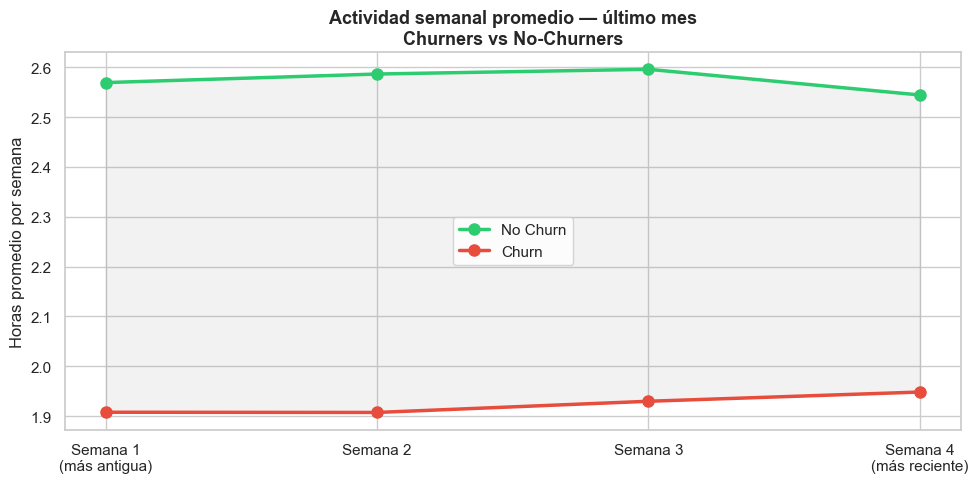

In [13]:
semanas   = ['horas_semana_1', 'horas_semana_2', 'horas_semana_3', 'horas_semana_4']
etiquetas = ['Semana 1\n(más antigua)', 'Semana 2', 'Semana 3', 'Semana 4\n(más reciente)']

media_no_churn = df[df['churn'] == 0][semanas].mean().values
media_churn    = df[df['churn'] == 1][semanas].mean().values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(etiquetas, media_no_churn, marker='o', color=COLOR_NO_CHURN,
        linewidth=2.5, markersize=8, label='No Churn')
ax.plot(etiquetas, media_churn,    marker='o', color=COLOR_CHURN,
        linewidth=2.5, markersize=8, label='Churn')
ax.fill_between(etiquetas, media_no_churn, media_churn, alpha=0.1, color='gray')

ax.set_title('Actividad semanal promedio — último mes\nChurners vs No-Churners',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Horas promedio por semana')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/07_tendencia_semanal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Matriz de correlación entre variables principales

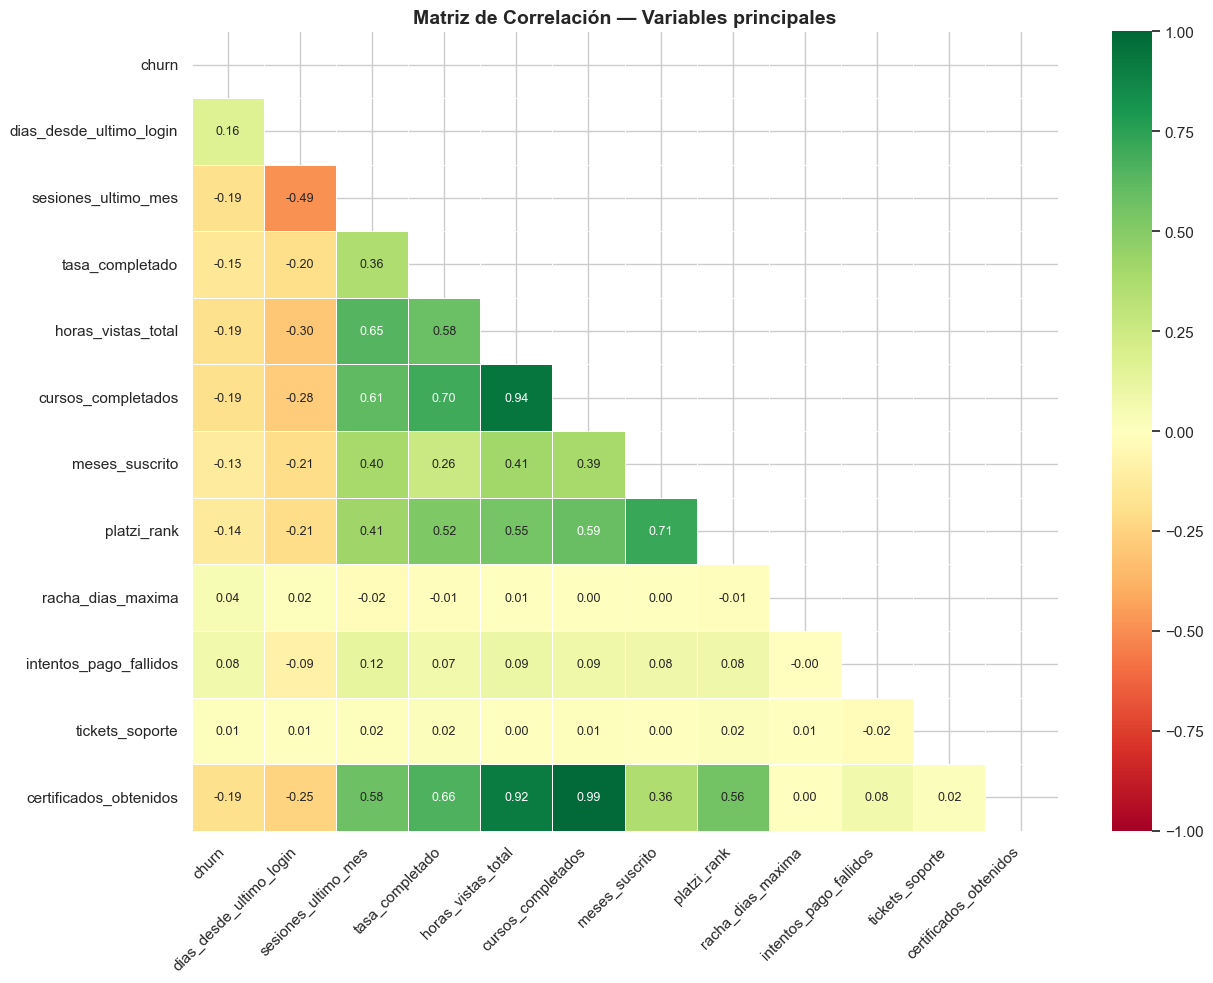

In [14]:
cols_heatmap = [
    'churn', 'dias_desde_ultimo_login', 'sesiones_ultimo_mes',
    'tasa_completado', 'horas_vistas_total', 'cursos_completados',
    'meses_suscrito', 'platzi_rank', 'racha_dias_maxima',
    'intentos_pago_fallidos', 'tickets_soporte', 'certificados_obtenidos'
]

matriz = df[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(
    matriz, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlación — Variables principales', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/08_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Nivel Rewards y Objetivo del estudiante

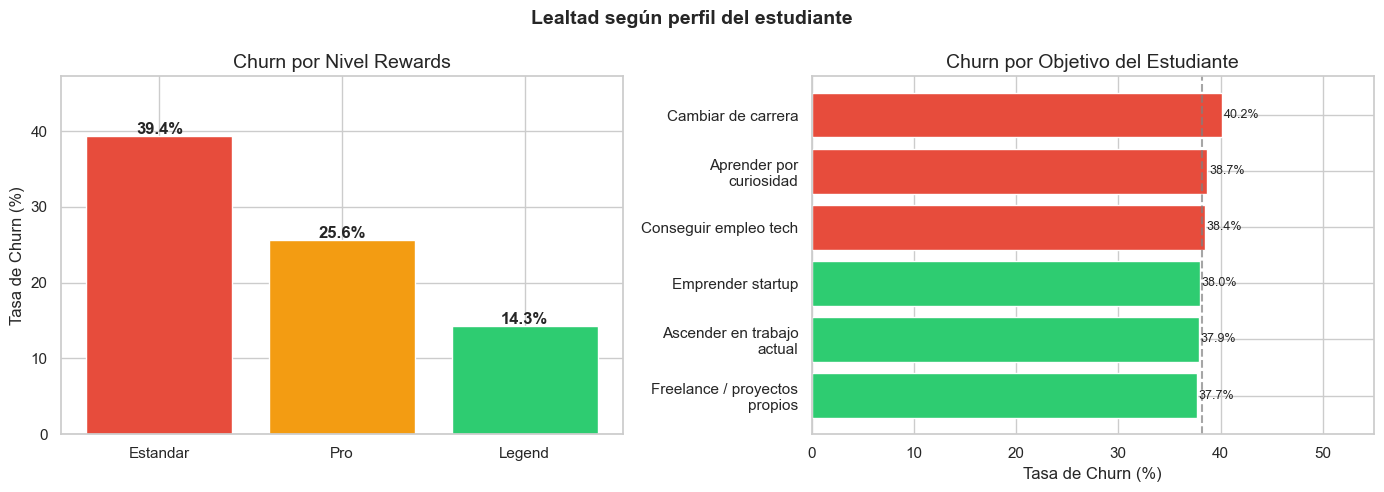

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn por nivel rewards
churn_nivel = df.groupby('nivel_rewards')['churn'].mean().sort_values(ascending=False) * 100
orden_nivel = ['Estandar', 'Pro', 'Legend']
churn_nivel = churn_nivel.reindex([n for n in orden_nivel if n in churn_nivel.index])

colores_nivel = [COLOR_CHURN, '#f39c12', COLOR_NO_CHURN]
bars0 = axes[0].bar(churn_nivel.index, churn_nivel.values,
                    color=colores_nivel[:len(churn_nivel)], edgecolor='white')
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn por Nivel Rewards')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_ylim(0, churn_nivel.max() * 1.2)

# Churn por objetivo
churn_obj = df.groupby('objetivo_estudiante')['churn'].mean().sort_values(ascending=True) * 100
churn_obj.index = churn_obj.index.str.wrap(22)

bars1 = axes[1].barh(churn_obj.index, churn_obj.values,
                     color=[COLOR_CHURN if v > df['churn'].mean()*100 else COLOR_NO_CHURN
                            for v in churn_obj.values],
                     edgecolor='white')
axes[1].axvline(df['churn'].mean()*100, color='gray', linestyle='--', alpha=0.7)
for bar in bars1:
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=9)
axes[1].set_title('Churn por Objetivo del Estudiante')
axes[1].set_xlabel('Tasa de Churn (%)')
axes[1].set_xlim(0, 55)

plt.suptitle('Lealtad según perfil del estudiante', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/09_churn_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Conclusiones para el modelo

In [16]:
print('=' * 60)
print('CONCLUSIONES DEL EDA — MODULO 1 CHURN')
print('=' * 60)

print(f"""
DATASET
  {len(df):,} estudiantes | {df.shape[1]} variables
  Churn rate: {df['churn'].mean():.1%}

VARIABLES MAS RELEVANTES PARA EL MODELO
  1. sesiones_ultimo_mes      -> principal señal de abandono
  2. dias_desde_ultimo_login  -> inactividad prolongada = churn
  3. tasa_completado          -> quien no completa cursos, se va
  4. horas_vistas_total       -> engagement acumulado en la plataforma
  5. plan                     -> Basic churna 3x mas que Expert Family

SEGMENTOS DE ALTO RIESGO
  Plan Basic:      {df[df['plan']=='Basic']['churn'].mean():.1%} de abandono
  Plan Gratuito:   {df[df['plan']=='Gratuito']['churn'].mean():.1%} de abandono

SEGMENTOS MAS LEALES
  Expert Family:   {df[df['plan']=='Expert Family']['churn'].mean():.1%} de abandono
  Expert Duo:      {df[df['plan']=='Expert Duo']['churn'].mean():.1%} de abandono

DECISIONES PARA EL PREPROCESAMIENTO
  - nps_score: imputar con mediana (nulos esperados en encuestas)
  - plan, escuela, pais: One-Hot Encoding
  - class_weight='balanced': compensar desbalance entre grupos
  - Escalar variables numericas: StandardScaler
""")
print('=' * 60)

CONCLUSIONES DEL EDA — MODULO 1 CHURN

DATASET
  5,000 estudiantes | 58 variables
  Churn rate: 38.2%

VARIABLES MAS RELEVANTES PARA EL MODELO
  1. sesiones_ultimo_mes      -> principal señal de abandono
  2. dias_desde_ultimo_login  -> inactividad prolongada = churn
  3. tasa_completado          -> quien no completa cursos, se va
  4. horas_vistas_total       -> engagement acumulado en la plataforma
  5. plan                     -> Basic churna 3x mas que Expert Family

SEGMENTOS DE ALTO RIESGO
  Plan Basic:      58.9% de abandono
  Plan Gratuito:   39.9% de abandono

SEGMENTOS MAS LEALES
  Expert Family:   19.1% de abandono
  Expert Duo:      23.3% de abandono

DECISIONES PARA EL PREPROCESAMIENTO
  - nps_score: imputar con mediana (nulos esperados en encuestas)
  - plan, escuela, pais: One-Hot Encoding
  - class_weight='balanced': compensar desbalance entre grupos
  - Escalar variables numericas: StandardScaler

